# MODELO DE PROJEÇÃO DE DEMANDA

**Autores:** Ruan Sardi / Paulo Musachio

**Área Responsável pelo Desenvolvimento:** Analytics

**Áreas Interessadas:** Dados, S&OP, MRP, Comercial

## Descrição do Notebook

Este notebook tem como objetivo desenvolver e aplicar modelos de previsão de vendas (quantidade) para diversas séries temporais, segmentadas por canal e subfamília de produto. Ele utiliza a biblioteca `mlforecast` e otimização de hiperparâmetros com `Optuna` para encontrar os melhores modelos de Machine Learning (LightGBM, XGBoost, RandomForest).

**Objetivos:**

1.  **Carga e Preparação de Dados:** Conectar-se ao BigQuery para extrair dados históricos de faturamento e realizar a limpeza, imputação de dados faltantes (usando interpolação linear) e filtragem de séries com histórico insuficiente ou sem variância.
2.  **Engenharia de Features:** Criar variáveis exógenas e transformações de lags para enriquecer o conjunto de dados para os modelos de previsão.
3.  **Otimização de Modelos:** Utilizar o Optuna para realizar a busca de hiperparâmetros, encontrando as melhores configurações para os modelos selecionados com base no MAPE (Mean Absolute Percentage Error) de validação cruzada.
4.  **Previsão de Vendas:** Gerar projeções de vendas para os próximos meses utilizando os modelos otimizados.
5.  **Avaliação de Desempenho:** Calcular o MAPE dos modelos no conjunto de teste para comparar a acurácia das previsões.
6.  **Exportação de Resultados:** Salvar as projeções e os erros dos modelos em tabelas no BigQuery, além de comparar o desempenho com modelos ARIMA e TimesFM gerados diretamente no BQML.

**Produtos gerados:**
- dux-data-analytics-prod.ds_modelos.projecoes_modelos_sop_por_canal
- dux-data-analytics-prod.ds_modelos.erros_modelos_sop_por_canal
- dux-data-analytics-prod.ds_modelos.projecoes_melhores_modelos_sop_por_canal

# Importando libs e carregando dados

In [1]:
# Importando libs
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
import shap

c:\Users\ruan.sardi\Desktop\GitHub repos\ds-projecoes-time-series-sop\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Autenticação
# É necessário executar o comando `gcloud auth application-default login` no Google Cloud SDK para autenticação

# Nome do projeto no GCP
client = bigquery.Client(project='dux-data-analytics-prod')

c:\Users\ruan.sardi\Desktop\GitHub repos\ds-projecoes-time-series-sop\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [3]:
query = """
-- AJUSTAR AS DATAS MENSALMENTE AQUI OU CONFORME NECESSIDADE
DECLARE data_inicial_ DATE DEFAULT '2023-01-01';
DECLARE data_final_ DATE DEFAULT '2026-07-01';

-- PARÂMETROS DA PROJEÇÃO DE NOVOS NEGOCIOS (AGO-DEZ/2026 A PARTIR DE AGO-DEZ/2025 + CRESCIMENTO)
DECLARE data_inicio_projecao_fonte_ DATE DEFAULT '2025-08-01';
DECLARE data_fim_projecao_fonte_ DATE DEFAULT '2025-12-01';
DECLARE fator_crescimento_projecao_ FLOAT64 DEFAULT 1.10; -- +10%

WITH TB_FATURAMENTO AS (
SELECT
    NF.competencia AS mes,
    NF.codigo_cliente,
    NF.loja_cliente,
    NF.documento_cliente,
    NF.canal_venda_nivel_2,
    NF.canal_venda_nivel_3,
    -- INICIO AJUSTES CANAIS PELA CARTEIRA
    CASE
        WHEN CLI.carteira_atual LIKE '%NOVOS NEGOCIOS%' THEN 'NOVOS NEGOCIOS'
        ELSE  NF.canal_venda_nivel_3_atual
    END AS canal_venda_nivel_3_atual,
    -- FIM AJUSTES CANAIS PELA CARTEIRA
    NF.codigo_produto,
    SUM(NF.quantidade) AS quantidade
FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item` AS NF
LEFT JOIN `dux-data-analytics-pub.clientes.dados_cadastrais_pessoa_juridica` AS CLI
    ON NF.codigo_cliente = CLI.codigo_cliente
    AND NF.loja_cliente = CLI.loja_cliente
    AND NF.documento_cliente = CLI.documento_cliente
WHERE 1=1
AND NF.competencia >= data_inicial_
GROUP BY ALL
)
, B2B AS (
SELECT
    NF.canal_venda_nivel_3_atual AS canal,
    NF.mes,
    NF.codigo_produto,
    CAST(SUM(NF.quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO AS NF
WHERE 1=1
AND NF.mes >= data_inicial_
AND NF.canal_venda_nivel_2 = 'B2B'
GROUP BY ALL
)
, B2C AS (
SELECT
    canal_venda_nivel_3 AS canal,
    mes,
    codigo_produto,
    CAST(SUM(quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO
WHERE 1=1
AND mes >= data_inicial_
AND canal_venda_nivel_2 = 'B2C'
GROUP BY ALL
)
, UNIAO AS (
SELECT * FROM B2B
UNION ALL
SELECT * FROM B2C
)
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, JUNCAO_QTD_SUBFAMILIA AS (
SELECT
    UNIAO.*,
    SUBFAMILIA.subfamilia_produto
FROM UNIAO
LEFT JOIN SUBFAMILIA
    ON UNIAO.codigo_produto = SUBFAMILIA.codigo_produto
)
, BASE_QUASE_FINALIZADA AS (
SELECT
    canal,
    mes,
    subfamilia_produto,
    SUM(quantidade) AS quantidade
FROM JUNCAO_QTD_SUBFAMILIA
WHERE 1=1
AND TRIM(subfamilia_produto) <> '' --Removendo registros sem subfamílias cadastradas
AND subfamilia_produto IS NOT NULL
AND canal IS NOT NULL --Removendo registros sem canal
AND canal <> 'INATIVOS' --Removendo INATIVOS
AND mes <= data_final_
GROUP BY ALL
)

-----------------------------------------------------------------------------
-------- REMOVENDO SUBFAMÍLIAS LANÇAMENTO, PHASE OUT OU INATIVOS ------------
-----------------------------------------------------------------------------

, LANCAMENTO_PHASEOUT_INATIVO AS (
-- Captura apenas os códigos que são Lançamento, Phase Out ou Inativos
SELECT DISTINCT codigo_produto FROM (
SELECT DISTINCT codigo_produto
FROM `dux-data-analytics-prod.zz_source_sop.aux_produtos_lancamento_phase_out`
WHERE TRIM(status_produto) NOT IN ('ATIVO')

UNION ALL

SELECT DISTINCT id_produto_protheus
FROM dux-data-analytics-pub.produtos.cadastro
WHERE nome_produto LIKE '%INATIVO%'
))
, VALIDA_LANCAMENTO_PHASEOUT_INATIVO AS (
-- Cruza as duas tabelas para identificar quem é lançamento, phase out ou inativo
SELECT
    b.subfamilia_produto,
    b.codigo_produto,
    CASE WHEN e.codigo_produto IS NOT NULL THEN 1 ELSE 0 END AS lancamento_phaseout_inativo
FROM SUBFAMILIA b
LEFT JOIN LANCAMENTO_PHASEOUT_INATIVO e
    ON b.codigo_produto = e.codigo_produto
)
, SUBFAM_LANCAMENTO_PHASEOUT_INATIVO AS (
SELECT
    subfamilia_produto,
    COUNT(codigo_produto) as total_produtos
FROM VALIDA_LANCAMENTO_PHASEOUT_INATIVO
GROUP BY subfamilia_produto
HAVING MIN(lancamento_phaseout_inativo) = 1
)
, BASE_SEM_PHASEOUT_LANC_INAT AS (
SELECT *
FROM BASE_QUASE_FINALIZADA
WHERE 1=1
AND subfamilia_produto NOT IN (SELECT subfamilia_produto FROM SUBFAM_LANCAMENTO_PHASEOUT_INATIVO)
)

-----------------------------------------------------------------------------
-------- PROJEÇÃO NOVOS NEGOCIOS: AGO-DEZ/2026 A PARTIR DE AGO-DEZ/2025 (+10%)
-----------------------------------------------------------------------------

, DADOS_PROJETADOS_NOVOS_NEGOCIOS AS (
SELECT
    canal,
    DATE_ADD(mes, INTERVAL 1 YEAR) AS mes,
    subfamilia_produto,
    CAST(ROUND(quantidade * fator_crescimento_projecao_) AS INT64) AS quantidade
FROM BASE_SEM_PHASEOUT_LANC_INAT
WHERE mes BETWEEN data_inicio_projecao_fonte_ AND data_fim_projecao_fonte_
AND canal = 'NOVOS NEGOCIOS'
)

-----------------------------------------------------------------------------
-------- PROJEÇÃO DEMAIS CANAIS: AGO-DEZ/2026 VINDO DE TABELA EXTERNA -------
-----------------------------------------------------------------------------

, PROJECAO_EXTERNA_UNPIVOT AS (
SELECT
    canal,
    mes,
    subfamilia_produto,
    CAST(ROUND(SUM(quantidade)) AS INT64) AS quantidade
FROM (
    SELECT
        canal,
        CASE mes_ref
            WHEN 'V_08_26' THEN DATE '2026-08-01'
            WHEN 'V_09_26' THEN DATE '2026-09-01'
            WHEN 'V_10_26' THEN DATE '2026-10-01'
            WHEN 'V_11_26' THEN DATE '2026-11-01'
            WHEN 'V_12_26' THEN DATE '2026-12-01'
        END AS mes,
        SUBFAMILIA AS subfamilia_produto,
        quantidade
    FROM `dux-data-analytics-prod.ds_modelos.projecao_sop_ate_final_do_ano`
    UNPIVOT(quantidade FOR mes_ref IN (V_08_26, V_09_26, V_10_26, V_11_26, V_12_26))
    WHERE 1=1
    AND canal <> 'NOVOS NEGOCIOS' -- esse canal usa a projeção por crescimento, não a tabela
    AND canal <> 'INATIVOS'
    AND SUBFAMILIA NOT IN (SELECT subfamilia_produto FROM SUBFAM_LANCAMENTO_PHASEOUT_INATIVO)
)
GROUP BY ALL
)

, HISTORICO_COMPLETO AS (
SELECT * FROM BASE_SEM_PHASEOUT_LANC_INAT
UNION ALL
SELECT * FROM DADOS_PROJETADOS_NOVOS_NEGOCIOS
UNION ALL
SELECT * FROM PROJECAO_EXTERNA_UNPIVOT
)

-----------------------------------------------------------------------------
-------- FILTRANDO SUBFAMILIAS PELA CURVA -----------------------------------
-----------------------------------------------------------------------------

, CURVA_SUBFAMILIA AS ( --DEFINO A CURVA DA SUBFAMILIA PELO PRODUTO COM A MELHOR CURVA NA SUBFAMILIA
SELECT
    B.subfamilia_produto,
    COALESCE(MIN(A.curva_abc), 'C') AS curva_abc
FROM `dux-data-analytics-pub.produtos.cadastro` AS B
LEFT JOIN `dux-data-analytics-pub.produtos.curva_abc` AS A
    ON B.id_produto_protheus = A.codigo_produto
WHERE COALESCE(TRIM(B.subfamilia_produto), '') <> ''
GROUP BY B.subfamilia_produto
)

SELECT
    A.*,
    COALESCE(B.curva_abc, 'C') AS curva_abc
FROM HISTORICO_COMPLETO A
LEFT JOIN CURVA_SUBFAMILIA B
    ON A.subfamilia_produto = B.subfamilia_produto
WHERE 1=1
"""

In [4]:
# Consulta do BQ transformada em dataframe
df = client.query(query).to_dataframe()

c:\Users\ruan.sardi\Desktop\GitHub repos\ds-projecoes-time-series-sop\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [7]:
# Variável exógena de aumento de preço

query_aumento_preco = """
SELECT
    canal,
    mes,
    aumento_preco
FROM `dux-data-analytics-prod.ds_modelos.feat_aumento_preco`
"""

df_aumento_preco = client.query(query_aumento_preco).to_dataframe()
df_aumento_preco['mes'] = pd.to_datetime(df_aumento_preco['mes'])

c:\Users\ruan.sardi\Desktop\GitHub repos\ds-projecoes-time-series-sop\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


# Preparação dos dados

In [9]:
# Quantidades de séries por curva de produto
df['chave'] = df['canal'] + df['subfamilia_produto']
df.groupby('curva_abc')['chave'].nunique()

curva_abc
A    208
B    212
C    792
Name: chave, dtype: int64

In [10]:
# Ajustando colunas
df['mes'] = pd.to_datetime(df['mes'])
df = df.sort_values(['canal','subfamilia_produto','mes'])

In [11]:
# Imputação de quantidade faltante
# Mês sem nota fiscal = ausência de venda (0), não erro de captura.
# Interpolação linear só cobre lacunas curtas (possível atraso de faturamento);
# lacunas longas viram 0 em vez de tendência fabricada. Pontas da série (antes da
# 1a venda / depois da última) permanecem NaN e são tratadas depois (dropna),
# pois significam "série ainda não existia" ou "parou de vender recentemente".

LIMITE_GAP_INTERPOLAVEL = 1  # meses consecutivos tratados como atraso, não ruptura real

# Identificando apenas as combinações que existem de fato
chaves = ['canal','subfamilia_produto','curva_abc']
series_existentes = df[chaves].drop_duplicates()

# Criando a linha do tempo completa (do mês mínimo ao máximo do dataset)
datas = pd.DataFrame({'mes': pd.date_range(df['mes'].min(), df['mes'].max(), freq='MS')})

# Criando o template: apenas as séries existentes cruzadas com todos os meses
df_template = series_existentes.merge(datas, how='cross')

# Trazendo os dados originais para o template
df_final = pd.merge(df_template, df, on=chaves + ['mes'], how='left')

# Ordenando para garantir que a interpolação siga a ordem cronológica
df_final = df_final.sort_values(by=chaves + ['mes'])

# Sinaliza o que era observado de fato, antes de qualquer preenchimento
df_final['imputado'] = df_final['quantidade'].isna()

# Imputação: interpola lacunas internas curtas; lacunas internas mais longas
# (ausência real de venda) viram 0; pontas continuam NaN.
# 'dentro_do_intervalo' marca as posições entre a 1a e a última venda real da
# série (fillna() não tem o parâmetro limit_area, por isso a máscara manual)
def imputar_serie(serie):
    interpolado = serie.interpolate(method='linear', limit=LIMITE_GAP_INTERPOLAVEL, limit_area='inside')
    valido = serie.notna()
    dentro_do_intervalo = valido.cummax() & valido[::-1].cummax()[::-1]
    interpolado = interpolado.mask(interpolado.isna() & dentro_do_intervalo, 0)
    return interpolado

df_final['quantidade'] = df_final.groupby(chaves)['quantidade'].transform(imputar_serie)

# Resetando o index para limpeza
df_com_inputacao = df_final.reset_index(drop=True)

# Visibilidade do quanto foi fabricado vs real
pct_imputado = df_com_inputacao['imputado'].mean()
print(f"% de mês-série imputados (interpolação ou zero): {pct_imputado:.1%}")

% de mês-série imputados (interpolação ou zero): 55.2%


In [12]:
# Removendo séries sem histórico real suficiente nos últimos 24 meses
# (usa a flag 'imputado' da célula anterior — não conta como "dado válido"
# um mês que foi fabricado por interpolação ou zerado por ausência de venda)

# Identificando os últimos 24 meses presentes no dataframe
ultimos_24_meses = sorted(df_com_inputacao['mes'].unique())[-24:]

# Definindo as colunas da série
cols_serie = ['canal','subfamilia_produto','curva_abc']

# Quantos meses podem ser fabricados (interpolados/zerados) sem invalidar a série
MIN_MESES_REAIS_ULTIMOS_24 = 24  # ajustar conforme tolerância do negócio

# Filtrando: a série deve ter pelo menos MIN_MESES_REAIS_ULTIMOS_24 meses REAIS
# (não imputados) dentre os últimos 24 meses
def possui_ultimos_24_com_dados(grupo):
    # Filtrando o grupo apenas para os meses que nos interessam
    ultimos_registros = grupo[grupo['mes'].isin(ultimos_24_meses)]

    # Contando quantos desses registros são venda REAL (não imputados)
    contagem_reais = (~ultimos_registros['imputado']).sum()

    return contagem_reais >= MIN_MESES_REAIS_ULTIMOS_24

df_filtrado = df_com_inputacao.groupby(cols_serie).filter(possui_ultimos_24_com_dados)

# --- Verificação ---
series_antes = df_com_inputacao[cols_serie].drop_duplicates().shape[0]
series_depois = df_filtrado[cols_serie].drop_duplicates().shape[0]

print(f"Séries totais antes: {series_antes}")
print(f"Séries com pelo menos {MIN_MESES_REAIS_ULTIMOS_24} meses reais nos últimos 24: {series_depois}")

Séries totais antes: 1212
Séries com pelo menos 24 meses reais nos últimos 24: 302


In [13]:
# Quantidade de séries excluídas devido a falta de histórico por curva
df_com_inputacao['chave'] = df_com_inputacao['canal'] + df_com_inputacao['subfamilia_produto']
df_filtrado['chave'] = df_filtrado['canal'] + df_filtrado['subfamilia_produto']
df_com_inputacao[~df_com_inputacao['chave'].isin(df_filtrado['chave'])].groupby('curva_abc')['chave'].nunique()

curva_abc
A     60
B    114
C    736
Name: chave, dtype: int64

In [14]:
# Removendo histórico sem valores de venda
df_filtrado = df_filtrado.dropna(subset=['quantidade'])

In [15]:
# Removendo séries flat
def tem_variacao(grupo):
    return grupo['quantidade'].nunique() > 1  # Retorna True se houver mais de um valor diferente

df_filtrado_final = df_filtrado.groupby(cols_serie).filter(tem_variacao)

In [16]:
# Adicionando a variável exógena de aumento de preço
df_filtrado_final = df_filtrado_final.merge(df_aumento_preco, on=['canal', 'mes'], how='left')
df_filtrado_final['aumento_preco'] = df_filtrado_final['aumento_preco'].fillna(0).astype(int)

In [20]:
# Preparação dos dados para StatsForecast/MLForecast
# Formato necessário: unique_id, ds (datetime), y (target): Requisitos na documentação

def preparar_dados_forecast(df):
    """
    Converte df para formato StatsForecast/MLForecast
    """
    df_forecast = df.copy()

    # Criar unique_id concatenando as dimensões
    df_forecast['unique_id'] = (
        df_forecast['canal'].astype(str) + '|||' +
        df_forecast['subfamilia_produto'].astype(str)
    )

    # Renomear colunas para formato padrão
    df_forecast = df_forecast.rename(columns={'mes': 'ds',
                                              'quantidade': 'y'})

    # Encoding da curva ABC
    df_forecast['curva_abc_encoded'] = df_forecast['curva_abc'].map({'A': 0, 'B': 1, 'C': 2}).astype(int)

    # Selecionar apenas colunas necessárias
    df_forecast = df_forecast[['unique_id','ds','y','curva_abc_encoded','aumento_preco']].copy()

    # Garantir que ds é datetime
    df_forecast['ds'] = pd.to_datetime(df_forecast['ds'])

    # Ordenar
    df_forecast = df_forecast.sort_values(['unique_id','ds']).reset_index(drop=True)

    return df_forecast

df_forecast = preparar_dados_forecast(df_filtrado_final)
print(f"Formato preparado: {df_forecast.shape}")
print(f"Número de séries únicas: {df_forecast['unique_id'].nunique()}")
print(f"\nPrimeiras linhas:")
print(df_forecast.head(10))

Formato preparado: (12464, 5)
Número de séries únicas: 302

Primeiras linhas:
              unique_id         ds      y  curva_abc_encoded  aumento_preco
0  1P|||COLLAGEN - 315G 2023-05-01  117.0                  1              0
1  1P|||COLLAGEN - 315G 2023-06-01  120.0                  1              0
2  1P|||COLLAGEN - 315G 2023-07-01   55.0                  1              0
3  1P|||COLLAGEN - 315G 2023-08-01   67.0                  1              0
4  1P|||COLLAGEN - 315G 2023-09-01   99.0                  1              0
5  1P|||COLLAGEN - 315G 2023-10-01  127.0                  1              0
6  1P|||COLLAGEN - 315G 2023-11-01  326.0                  1              0
7  1P|||COLLAGEN - 315G 2023-12-01   70.0                  1              0
8  1P|||COLLAGEN - 315G 2024-01-01   33.0                  1              0
9  1P|||COLLAGEN - 315G 2024-02-01  290.0                  1              0


# Modelagem

## Modelos ML

In [21]:
# ============================================================
# DEFINIÇÃO CENTRALIZADA DE COLUNAS DO PIPELINE
# Qualquer feature nova entra aqui e propaga para todo o código
# ============================================================
ID_COL     = 'unique_id'
TIME_COL   = 'ds'
TARGET_COL = 'y'

STATIC_COLS = ['curva_abc_encoded']
DYNAMIC_COLS = ['aumento_preco']
CORE_COLS  = [ID_COL, TIME_COL, TARGET_COL]
TRAIN_COLS = CORE_COLS + STATIC_COLS + DYNAMIC_COLS

In [22]:
# ================================================================
# Função utilitária — substituição de valores negativos por zeros
# ================================================================
def clamp_predictions(df_preds, model_cols, floor=0):
    """Garante que previsões de quantidade não fiquem negativas."""
    df_out = df_preds.copy()
    for col in model_cols:
        df_out[col] = np.maximum(df_out[col], floor)
    return df_out

In [23]:
# ============================================================
# SEPARAÇÃO TREINO / TESTE (ANTES de qualquer coisa)
# Reserva os últimos [periodo_teste] meses como teste final.
# ============================================================
periodo_teste = 3

cutoff = df_forecast['ds'].sort_values().unique()[-periodo_teste]

df_train = df_forecast[df_forecast['ds'] < cutoff].copy()
df_test  = df_forecast[df_forecast['ds'] >= cutoff].copy()

print(f"Treino: até {df_train['ds'].max().strftime('%b/%Y')}")
print(f"Teste:  de  {df_test['ds'].min().strftime('%b/%Y')} "
      f"até {df_test['ds'].max().strftime('%b/%Y')} "
      f"({df_test['ds'].nunique()} meses reservados)")

Treino: até Sep/2026
Teste:  de  Oct/2026 até Dec/2026 (3 meses reservados)


In [24]:
# ============================================================
# DEFINIÇÃO DAS TRANSFORMAÇÕES: CRIAÇÃO DE FEATURES
# ============================================================
MY_LAG_TRANSFORMS = {
    1: [RollingMean(window_size=2), RollingMean(window_size=6), RollingStd(window_size=3)],
    3: [RollingMean(window_size=2)],
    6: [RollingMean(window_size=2)]
}
MY_LAGS          = [1, 2, 3]
MY_DATE_FEATURES = ['month', 'quarter', 'year']

In [26]:
# ============================================================
# FUNÇÕES OBJETIVO INDEPENDENTES POR MODELO
# Cada modelo tem seu próprio espaço de busca e seu próprio budget de trials
# — evita que o Optuna "gaste" trials aprendendo qual modelo é melhor em vez
# de otimizar hiperparâmetros dentro de cada um.
# ============================================================
def make_objective(model_name):
    def objective(trial):
        if model_name == "LightGBM":
            params = {
                "n_estimators":  trial.suggest_int("n_estimators", 20, 200),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
                "max_depth":     trial.suggest_int("max_depth", 3, 5),
                "verbosity": -1,
            }
            model = LGBMRegressor(**params, random_state=22)
        elif model_name == "XGBoost":
            params = {
                "n_estimators":  trial.suggest_int("n_estimators", 20, 200),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
                "max_depth":     trial.suggest_int("max_depth", 3, 5),
            }
            model = XGBRegressor(**params, random_state=22)
        else:  # RandomForest
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 50, 300),
                "max_depth":        trial.suggest_int("max_depth", 3, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 20),
            }
            model = RandomForestRegressor(**params, random_state=22, n_jobs=-1)

        mlf = MLForecast(
            models=[model], freq='MS', lags=MY_LAGS,
            lag_transforms=MY_LAG_TRANSFORMS, date_features=MY_DATE_FEATURES,
        )
        cv_res = mlf.cross_validation(
            df=df_train[TRAIN_COLS].copy(), h=periodo_teste,
            n_windows=3, static_features=STATIC_COLS,
        )
        model_col = model.__class__.__name__
        cv_res = clamp_predictions(cv_res, [model_col])

        y_true, y_pred = cv_res['y'].values, cv_res[model_col].values
        mask = y_true != 0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))
    return objective

In [27]:
# ============================================================
# EXECUTAR OTIMIZAÇÃO — UM STUDY INDEPENDENTE POR MODELO
# ============================================================
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suprime logs repetitivos

N_TRIALS_PER_MODEL = 70  # ajustar conforme orçamento de tempo disponível

studies = {}
for model_name in ["LightGBM", "XGBoost", "RandomForest"]:
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=22),  # reprodutibilidade mês a mês
    )
    study.optimize(make_objective(model_name), n_trials=N_TRIALS_PER_MODEL)
    studies[model_name] = study
    print(f"{model_name}: MAPE(val)={study.best_value:.4f} | params={study.best_params}")

LightGBM: MAPE(val)=2.2621 | params={'n_estimators': 189, 'learning_rate': 0.12386552628899472, 'max_depth': 5}
XGBoost: MAPE(val)=1.9303 | params={'n_estimators': 189, 'learning_rate': 0.1412274342953716, 'max_depth': 4}
RandomForest: MAPE(val)=2.3574 | params={'n_estimators': 266, 'max_depth': 10, 'min_samples_leaf': 20}


In [28]:
# ============================================================
# MELHORES PARÂMETROS POR MODELO
# ============================================================
best_per_model = {name: study.best_params for name, study in studies.items()}
print(best_per_model)

{'LightGBM': {'n_estimators': 189, 'learning_rate': 0.12386552628899472, 'max_depth': 5}, 'XGBoost': {'n_estimators': 189, 'learning_rate': 0.1412274342953716, 'max_depth': 4}, 'RandomForest': {'n_estimators': 266, 'max_depth': 10, 'min_samples_leaf': 20}}


In [31]:
# ==================================================================
# PROJEÇÃO DOS PRÓXIMOS qtd_meses_projecao MESES: AMBOS OS MODELOS
# ==================================================================
qtd_meses_projecao = 12  # AJUSTAR PARA A QUANTIDADE DE MESES QUE DESEJA PREVER

# 1. Instanciar os dois modelos com os melhores parâmetros encontrados pelo Optuna
lgb_model = LGBMRegressor(
    **best_per_model['LightGBM'], random_state=22, verbosity=-1
)

xgb_model = XGBRegressor(
    **best_per_model['XGBoost'], random_state=22
)

rf_model = RandomForestRegressor(
    **best_per_model['RandomForest'], random_state=22, n_jobs=-1
)

mlf_both = MLForecast(
    models={"LightGBM": lgb_model, "XGBoost": xgb_model, "RandomForest": rf_model},
    freq='MS',
    lags=MY_LAGS,
    lag_transforms=MY_LAG_TRANSFORMS,
    date_features=MY_DATE_FEATURES,
)

mlf_both.fit(df_forecast[TRAIN_COLS], static_features=STATIC_COLS)

# Valor FUTURO/planejado de aumento_preco para o(s) mes(es) da projeção —
# precisa vir do planejamento comercial/ICOM/Pricing (a própria tabela feat_aumento_preco,
# assumindo que ela já é alimentada com antecedência para o mês projetado)
datas_projecao = pd.date_range(
    start=df_forecast['ds'].max() + pd.offsets.MonthBegin(1),
    periods=qtd_meses_projecao, freq='MS'
)
ids_projecao = df_forecast[[ID_COL]].drop_duplicates()
X_df_projecao = ids_projecao.merge(pd.DataFrame({TIME_COL: datas_projecao}), how='cross')
X_df_projecao['canal'] = X_df_projecao[ID_COL].str.split('|||', expand=True)[0]

X_df_projecao = X_df_projecao.merge(
    df_aumento_preco.rename(columns={'mes': TIME_COL}),
    on=['canal', TIME_COL], how='left'
)
X_df_projecao['aumento_preco'] = X_df_projecao['aumento_preco'].fillna(0).astype(int)
X_df_projecao = X_df_projecao[[ID_COL, TIME_COL] + DYNAMIC_COLS]

df_projecao = mlf_both.predict(h=qtd_meses_projecao, X_df=X_df_projecao)
df_projecao = clamp_predictions(df_projecao, ['LightGBM','XGBoost','RandomForest'])
df_projecao = df_projecao[['unique_id','ds','LightGBM','XGBoost','RandomForest']]

print(df_projecao.head(10))

              unique_id         ds    LightGBM     XGBoost  RandomForest
0  1P|||COLLAGEN - 315G 2027-01-01  207.703420  155.831909    292.839431
1  1P|||COLLAGEN - 315G 2027-02-01  312.620571  331.203735    293.747398
2  1P|||COLLAGEN - 315G 2027-03-01  345.113128  388.962219    310.040040
3  1P|||COLLAGEN - 315G 2027-04-01  337.011667  317.924774    334.880532
4  1P|||COLLAGEN - 315G 2027-05-01  313.765928  275.195099    351.568114
5  1P|||COLLAGEN - 315G 2027-06-01  313.765928  266.701599    400.832694
6  1P|||COLLAGEN - 315G 2027-07-01  313.765928  255.440292    425.721094
7  1P|||COLLAGEN - 315G 2027-08-01  310.816596  255.440292    430.529862
8  1P|||COLLAGEN - 315G 2027-09-01  443.211571  342.917999    437.757343
9  1P|||COLLAGEN - 315G 2027-10-01  502.296598  354.179138    441.300867



=== SHAP — LightGBM ===


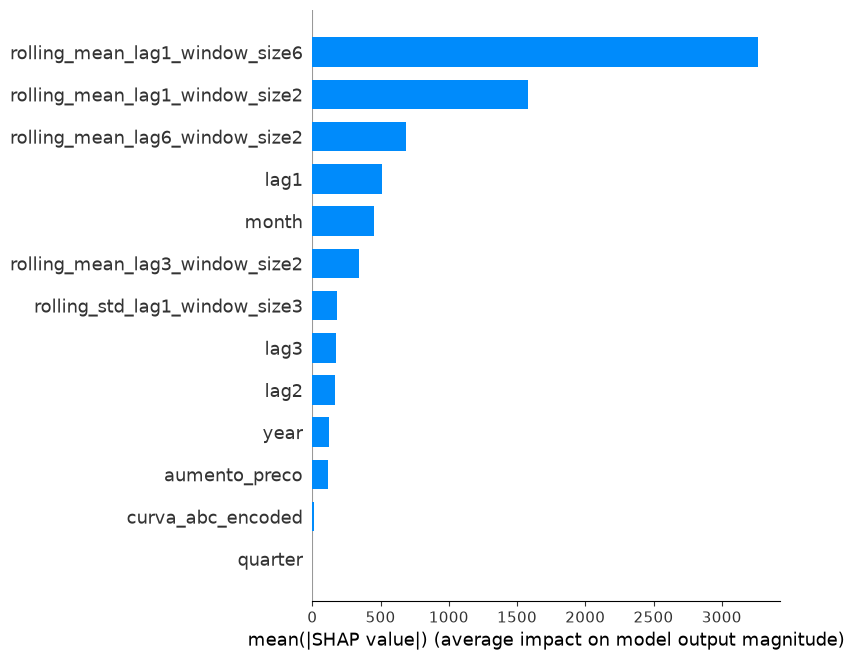

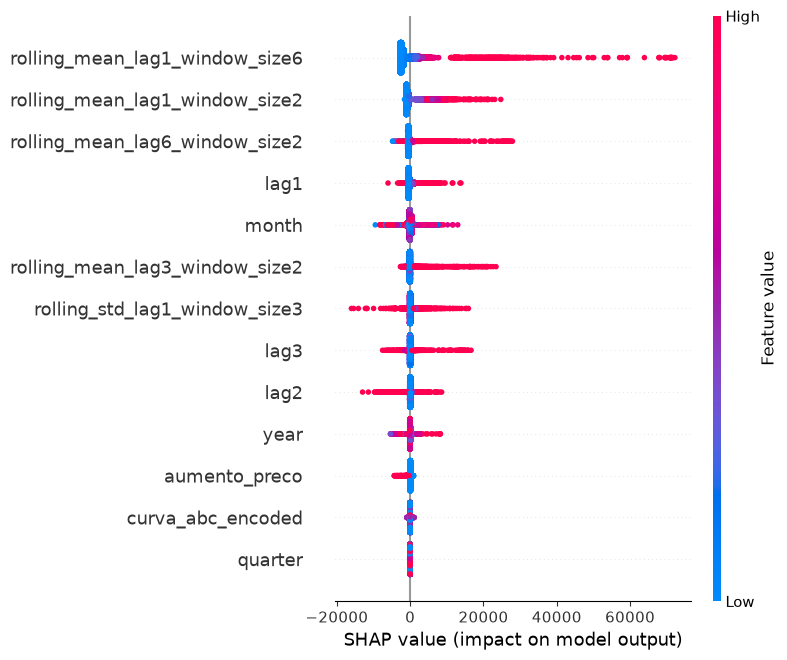


=== SHAP — XGBoost ===


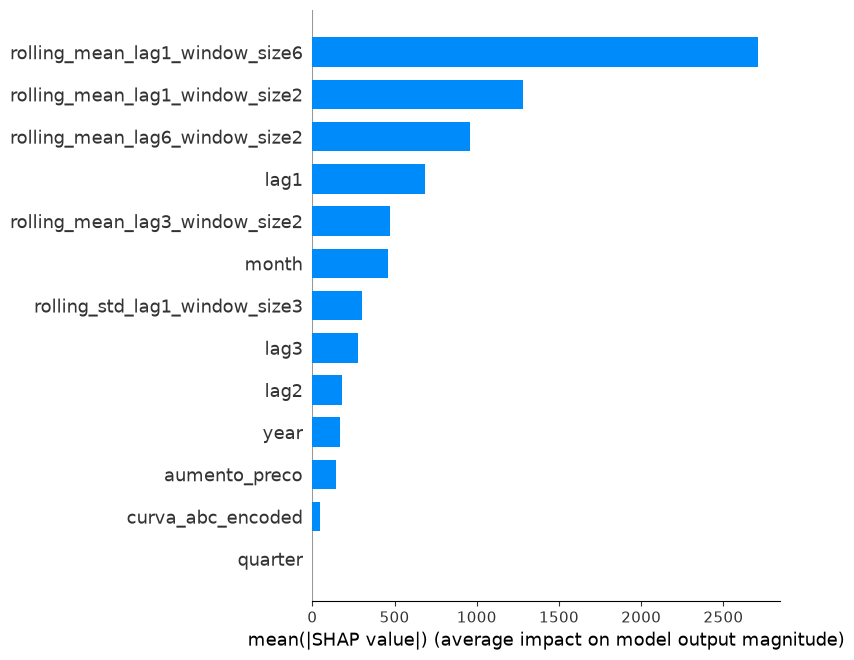

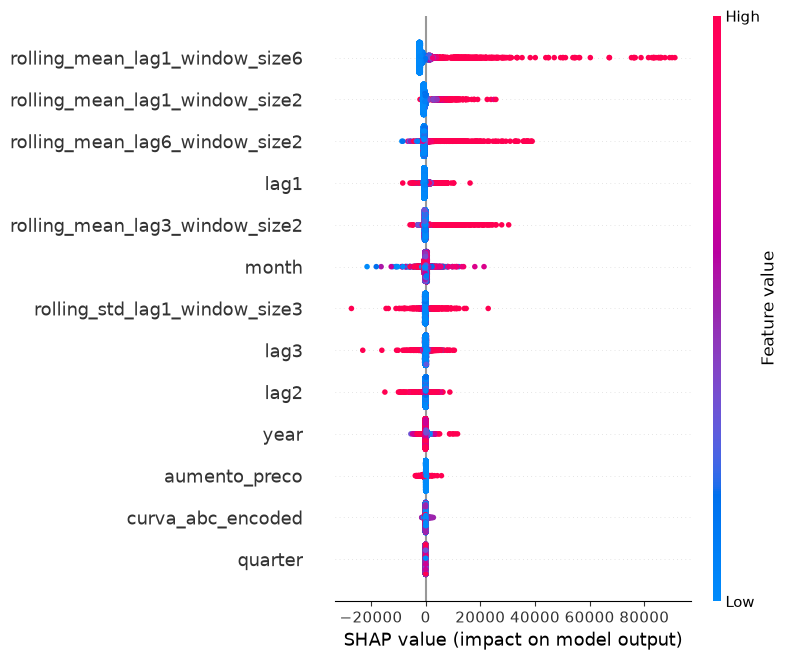


=== SHAP — RandomForest ===


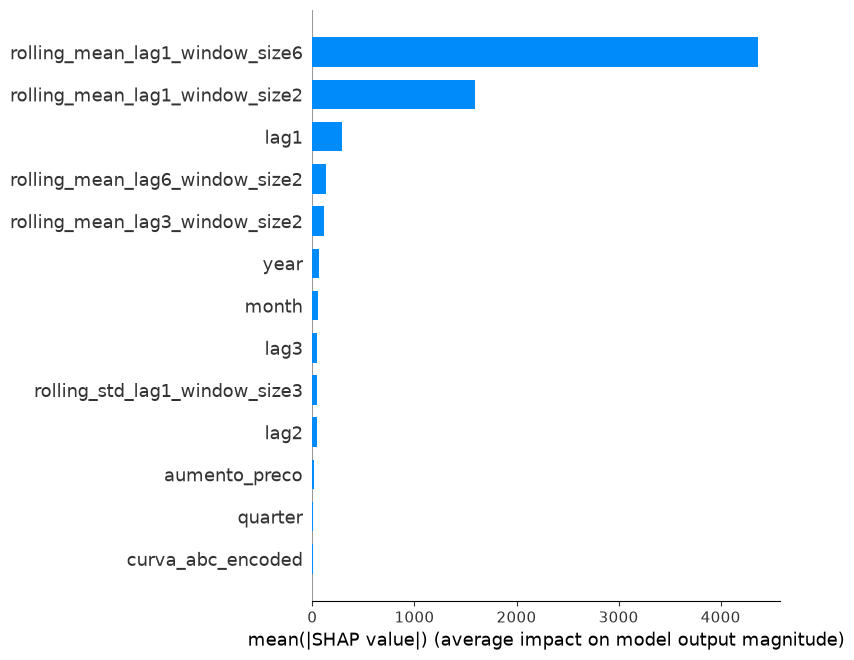

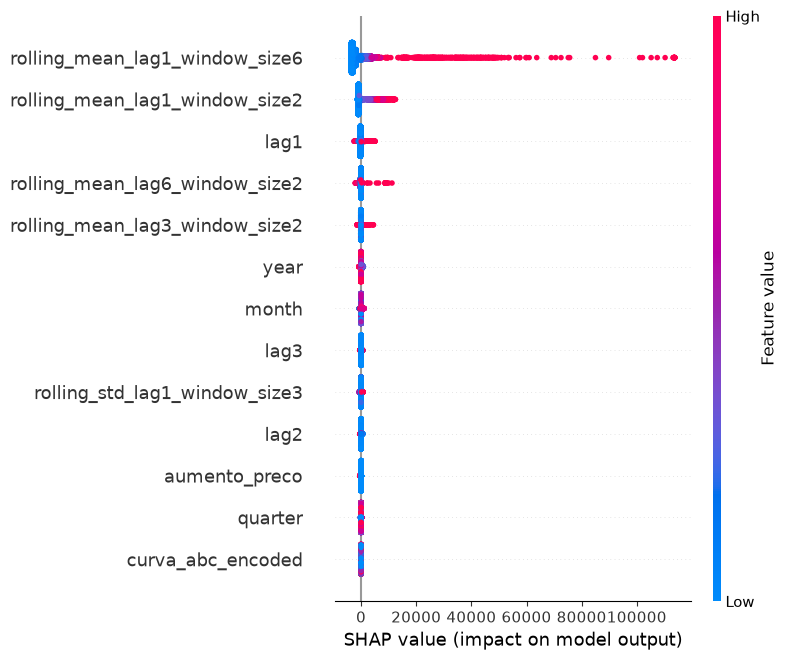

In [30]:
# Feature Importance com SHAP

# 1. Reconstrói a matriz de features EXATA usada no fit da célula 27
#    (mesmos lags, rolling, date features, static features)
X_treino = mlf_both.preprocess(df_forecast[TRAIN_COLS], static_features=STATIC_COLS)
X_treino = X_treino.drop(columns=[ID_COL, TIME_COL, TARGET_COL])

resultados_shap = {}

# 2. Um TreeExplainer por modelo (funciona nativamente para os 3 tipos)
for nome_modelo, modelo in mlf_both.models_.items():
    print(f"\n=== SHAP — {nome_modelo} ===")
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X_treino)
    resultados_shap[nome_modelo] = shap_values

    # Ranking simples de importância (média do |SHAP| por feature)
    shap.summary_plot(shap_values, X_treino, plot_type="bar", show=True)

    # Visão completa: importância + direção do efeito (feature alta/baixa
    # empurra a previsão para cima ou para baixo)
    shap.summary_plot(shap_values, X_treino, show=True)

In [33]:
# ============================================================
# MAPE POR SÉRIE — AMBOS OS MODELOS NO CONJUNTO DE TESTE
# ============================================================
h_test = df_test['ds'].nunique()

# 1. Treinar ambos os modelos em df_train
mlf_both.fit(df_train[TRAIN_COLS], static_features=STATIC_COLS)

# 2. Prever no horizonte de teste passando as variáveis exógenas
X_df_teste = df_test[[ID_COL, TIME_COL] + DYNAMIC_COLS].copy()

preds_both = mlf_both.predict(h=h_test, X_df=X_df_teste)
preds_both = clamp_predictions(preds_both, ['LightGBM','XGBoost','RandomForest'])

# 3. Merge com os valores reais
df_eval_both = df_test.merge(preds_both, on=['unique_id','ds'], how='left')

# 4. Calcular MAPE por linha para cada modelo
df_eval_both['mape_lightgbm'] = np.abs(
    (df_eval_both['y'] - df_eval_both['LightGBM']) /
    np.where(df_eval_both['y'] == 0, 1, df_eval_both['y'])
)

df_eval_both['mape_xgboost'] = np.abs(
    (df_eval_both['y'] - df_eval_both['XGBoost']) /
    np.where(df_eval_both['y'] == 0, 1, df_eval_both['y'])
)

df_eval_both['mape_rforest'] = np.abs(
    (df_eval_both['y'] - df_eval_both['RandomForest']) /
    np.where(df_eval_both['y'] == 0, 1, df_eval_both['y'])
)

# 5. Agrupar por série
df_mape_ambos = (
    df_eval_both
    .groupby('unique_id')[['mape_lightgbm','mape_xgboost','mape_rforest']]
    .mean()
    .reset_index()
)

df_mape_ambos['mape_lightgbm'] = (df_mape_ambos['mape_lightgbm']).round(4)
df_mape_ambos['mape_xgboost']  = (df_mape_ambos['mape_xgboost']).round(4)
df_mape_ambos['mape_rforest']  = (df_mape_ambos['mape_rforest']).round(4)

print(df_mape_ambos.head())

                            unique_id  mape_lightgbm  mape_xgboost  \
0                1P|||COLLAGEN - 315G         0.4845         0.647   
1  1P|||CREATINA MONOHIDRATADA - 300G         0.3211        1.1886   
2            1P|||ENERGY KICK - 1000G         0.2996        0.3465   
3   1P|||ENERGY KICK CAFFEINE - 1000G         0.2298        0.3715   
4              1P|||FRESH WHEY - 450G         0.1461        0.2081   

   mape_rforest  
0        0.3764  
1        0.2424  
2        0.3074  
3          0.28  
4        0.1798  


In [34]:
# Retornando com as colunas originais
df_mape_ambos[['canal','subfamilia_produto']] = df_mape_ambos['unique_id'].str.split('|||', expand=True, regex=False)
df_projecao[['canal','subfamilia_produto']] = df_projecao['unique_id'].str.split('|||', expand=True, regex=False)

df_mape_ambos = df_mape_ambos.drop(columns=['unique_id'])
df_projecao = df_projecao.drop(columns=['unique_id'])

In [35]:
# Ajustando df para estrutura da tabela no BQ
df_projecao_longo = df_projecao.melt(id_vars=['ds','canal','subfamilia_produto'],
                                     value_vars=['LightGBM','XGBoost','RandomForest'],
                                     var_name='modelo',
                                     value_name='projecao')

df_mape_longo = df_mape_ambos.melt(id_vars=['canal','subfamilia_produto'],
                                   value_vars=['mape_lightgbm','mape_xgboost','mape_rforest'],
                                   var_name='modelo',
                                   value_name='mape')

In [36]:
# Renomeando colunas para o formato da tabela no BQ
df_projecao_longo = df_projecao_longo.rename(columns={'ds':'mes'})

In [37]:
# Ajustando tipo
df_projecao_longo['projecao'] = df_projecao_longo['projecao'].round(0).astype(int)

In [38]:
# Renomeando mape pelo nome do modelo
df_mape_longo.loc[df_mape_longo['modelo'] == 'mape_lightgbm', 'modelo'] = 'LightGBM'
df_mape_longo.loc[df_mape_longo['modelo'] == 'mape_xgboost', 'modelo'] = 'XGBoost'
df_mape_longo.loc[df_mape_longo['modelo'] == 'mape_rforest', 'modelo'] = 'RandomForest'

# Exportação de resultados para o BQ

In [39]:
# Importando libs
from google.cloud import bigquery
import pandas_gbq
import pytz
from datetime import datetime, timedelta

In [40]:
# Data de hoje
timezone = pytz.timezone('America/Sao_Paulo')
d1_date = datetime.now(timezone)
timestamp_yyyymmdd = d1_date.strftime("%Y-%m-%d")

## Resultados de projeções dos modelos

**PONTOS IMPORTANTES:**


*   Mensalmente atualizar nas consultas as datas que estão declaradas em “DECLARE…” no início da consulta
*   Mensalmente atualizar nas consultas o nome do modelo após criar o modelo mais atualizado pelo BQML

In [41]:
# Gerando e executando a procedure com os modelos gerados pelo BQML (AJUSTAR AS DATAS QUE ESTÃO EM "DECLARE..." CONFORME NECESSIDADE)

procedure_sql = """
CREATE OR REPLACE PROCEDURE `dux-data-analytics-prod.ds_modelos.atualiza_projecoes_modelos_sop_por_canal`()
BEGIN

-- AJUSTAR AS DATAS MENSALMENTE AQUI OU CONFORME NECESSIDADE (DATAS SÃO INCLUSIVAS)
DECLARE data_inicio_base DATE DEFAULT '2023-01-01';
DECLARE data_fim_base DATE DEFAULT '2026-07-01';
DECLARE data_inicio_projecao DATE DEFAULT '2027-01-01'; --ago-dez/2026 agora é histórico (sintético)
DECLARE data_fim_projecao DATE DEFAULT '2027-12-01';

-- PARÂMETROS DO HISTÓRICO SINTÉTICO NOVOS NEGOCIOS (AGO-DEZ/2026 = AGO-DEZ/2025 x FATOR)
DECLARE data_inicio_periodo_fonte_sintetica DATE DEFAULT '2025-08-01';
DECLARE data_fim_periodo_fonte_sintetica DATE DEFAULT '2025-12-01';
DECLARE fator_crescimento_sintetico FLOAT64 DEFAULT 1.10;

CREATE OR REPLACE TABLE `dux-data-analytics-prod.ds_modelos.projecoes_modelos_sop_por_canal` AS

WITH MODELO_ARIMA AS (
----------------------------------------------
------------- INÍCIO MODELO ARIMA ------------
----------------------------------------------
WITH TB_FATURAMENTO AS (
SELECT
    NF.competencia AS mes,
    NF.codigo_cliente,
    NF.loja_cliente,
    NF.documento_cliente,
    NF.canal_venda_nivel_2,
    NF.canal_venda_nivel_3,
    -- INICIO AJUSTES CANAIS PELA CARTEIRA
    CASE
        WHEN CLI.carteira_atual LIKE '%NOVOS NEGOCIOS%' THEN 'NOVOS NEGOCIOS'
        ELSE  NF.canal_venda_nivel_3_atual
    END AS canal_venda_nivel_3_atual,
    -- FIM AJUSTES CANAIS PELA CARTEIRA
    NF.codigo_produto,
    SUM(NF.quantidade) AS quantidade
FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item` AS NF
LEFT JOIN `dux-data-analytics-pub.clientes.dados_cadastrais_pessoa_juridica` AS CLI
    ON NF.codigo_cliente = CLI.codigo_cliente
    AND NF.loja_cliente = CLI.loja_cliente
    AND NF.documento_cliente = CLI.documento_cliente
WHERE 1=1
AND NF.competencia >= data_inicio_base
GROUP BY ALL
)
, B2B AS (
SELECT
    NF.canal_venda_nivel_3_atual AS canal,
    NF.mes,
    NF.codigo_produto,
    CAST(SUM(NF.quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO AS NF
WHERE 1=1
AND NF.mes >= data_inicio_base
AND NF.canal_venda_nivel_2 = 'B2B'
GROUP BY ALL
)
, B2C AS (
SELECT
    canal_venda_nivel_3 AS canal,
    mes,
    codigo_produto,
    CAST(SUM(quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO
WHERE 1=1
AND mes >= data_inicio_base
AND canal_venda_nivel_2 = 'B2C'
GROUP BY ALL
)
, UNIAO AS (
SELECT * FROM B2B
UNION ALL
SELECT * FROM B2C
)
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, JUNCAO_QTD_SUBFAMILIA AS (
SELECT
    UNIAO.*,
    SUBFAMILIA.subfamilia_produto
FROM UNIAO
LEFT JOIN SUBFAMILIA
    ON UNIAO.codigo_produto = SUBFAMILIA.codigo_produto
)
, REAL AS (
SELECT
    canal,
    mes,
    subfamilia_produto,
    SUM(quantidade) AS real
FROM JUNCAO_QTD_SUBFAMILIA
WHERE 1=1
AND COALESCE(TRIM(subfamilia_produto), '') <> ''
AND subfamilia_produto IS NOT NULL
AND canal IS NOT NULL
AND mes >= data_inicio_projecao
AND mes <= data_fim_projecao
GROUP BY ALL
)
, PROJECTION AS (
SELECT
    CAST(forecast_timestamp AS DATE) AS mes,
    canal,
    subfamilia_produto,
    CASE
      WHEN CAST(forecast_value AS INT) < 0 THEN 0
      ELSE CAST(forecast_value AS INT)
    END AS projecao
FROM
    ML.FORECAST(MODEL `dux-data-analytics-prod.ds_modelos.202612_arima_qtd_itens_subfamilia_canal_mes`, --ATUALIZAR MODELO AQUI (retreinado com histórico sintético até dez/2026)
    STRUCT(50 AS horizon, 0.7 AS confidence_level)) AS PROJECTION
WHERE 1=1
AND TRIM(subfamilia_produto) <> ''
AND CAST(forecast_timestamp AS DATE) >= data_inicio_projecao
AND CAST(forecast_timestamp AS DATE) <= data_fim_projecao
)
SELECT
    PROJECTION.*,
    COALESCE(REAL.real, 0) AS real
FROM PROJECTION
LEFT JOIN REAL
    ON PROJECTION.subfamilia_produto = REAL.subfamilia_produto
    AND PROJECTION.canal = REAL.canal
    AND PROJECTION.mes = REAL.mes
ORDER BY PROJECTION.subfamilia_produto, PROJECTION.canal, PROJECTION.mes
)

----------------------------------------------
------------- FIM MODELO ARIMA ---------------
----------------------------------------------


, MODELO_TIMESFM AS (
------------------------------------------------
------------- INÍCIO MODELO TIMESFM ------------
------------------------------------------------
WITH PROJECTION AS (
SELECT
    forecast_timestamp,
    canal,
    subfamilia_produto,
    forecast_value,
    prediction_interval_lower_bound,
    prediction_interval_upper_bound
FROM
  AI.FORECAST(
    (
WITH TB_FATURAMENTO AS (
SELECT
    NF.competencia AS mes,
    NF.codigo_cliente,
    NF.loja_cliente,
    NF.documento_cliente,
    NF.canal_venda_nivel_2,
    NF.canal_venda_nivel_3,
    -- INICIO AJUSTES CANAIS PELA CARTEIRA
    CASE
        WHEN CLI.carteira_atual LIKE '%NOVOS NEGOCIOS%' THEN 'NOVOS NEGOCIOS'
        ELSE  NF.canal_venda_nivel_3_atual
    END AS canal_venda_nivel_3_atual,
    -- FIM AJUSTES CANAIS PELA CARTEIRA
    NF.codigo_produto,
    SUM(NF.quantidade) AS quantidade
FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item` AS NF
LEFT JOIN `dux-data-analytics-pub.clientes.dados_cadastrais_pessoa_juridica` AS CLI
    ON NF.codigo_cliente = CLI.codigo_cliente
    AND NF.loja_cliente = CLI.loja_cliente
    AND NF.documento_cliente = CLI.documento_cliente
WHERE 1=1
AND NF.competencia >= data_inicio_base
GROUP BY ALL
)
, B2B AS (
SELECT
    NF.canal_venda_nivel_3_atual AS canal,
    NF.mes,
    NF.codigo_produto,
    CAST(SUM(NF.quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO AS NF
WHERE 1=1
AND NF.mes >= data_inicio_base
AND NF.canal_venda_nivel_2 = 'B2B'
GROUP BY ALL
)
, B2C AS (
SELECT
    canal_venda_nivel_3 AS canal,
    mes,
    codigo_produto,
    CAST(SUM(quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO
WHERE 1=1
AND mes >= data_inicio_base
AND canal_venda_nivel_2 = 'B2C'
GROUP BY ALL
)
, UNIAO AS (
SELECT * FROM B2B
UNION ALL
SELECT * FROM B2C
)
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, JUNCAO_QTD_SUBFAMILIA AS (
SELECT
    UNIAO.*,
    SUBFAMILIA.subfamilia_produto
FROM UNIAO
LEFT JOIN SUBFAMILIA
    ON UNIAO.codigo_produto = SUBFAMILIA.codigo_produto
)
, HISTORICO_REAL AS (
  SELECT
      canal,
      mes,
      subfamilia_produto,
      SUM(quantidade) AS quantidade
  FROM JUNCAO_QTD_SUBFAMILIA
  WHERE 1=1
  AND TRIM(subfamilia_produto) <> '' --Removendo registros sem subfamílias cadastradas
  AND canal IS NOT NULL --Removendo registros sem canal
  AND mes <= data_fim_base -- garante que não entra nota parcial do mês corrente (ex: ago/2026 incompleto)
  GROUP BY ALL
)

-----------------------------------------------------------------------------
-------- SINTÉTICO NOVOS NEGOCIOS: AGO-DEZ/2026 A PARTIR DE AGO-DEZ/2025 (+10%)
-----------------------------------------------------------------------------

, HISTORICO_SINTETICO_NOVOS_NEGOCIOS AS (
  SELECT
      canal,
      DATE_ADD(mes, INTERVAL 1 YEAR) AS mes,
      subfamilia_produto,
      CAST(ROUND(quantidade * fator_crescimento_sintetico) AS INT64) AS quantidade
  FROM HISTORICO_REAL
  WHERE mes BETWEEN data_inicio_periodo_fonte_sintetica AND data_fim_periodo_fonte_sintetica
  AND canal = 'NOVOS NEGOCIOS'
)

-----------------------------------------------------------------------------
-------- SINTÉTICO DEMAIS CANAIS: AGO-DEZ/2026 VINDO DE TABELA EXTERNA ------
-----------------------------------------------------------------------------

, HISTORICO_SINTETICO_DEMAIS_CANAIS AS (
  SELECT
      canal,
      mes,
      subfamilia_produto,
      CAST(ROUND(SUM(quantidade)) AS INT64) AS quantidade
  FROM (
      SELECT
          canal,
          CASE mes_ref
              WHEN 'V_08_26' THEN DATE '2026-08-01'
              WHEN 'V_09_26' THEN DATE '2026-09-01'
              WHEN 'V_10_26' THEN DATE '2026-10-01'
              WHEN 'V_11_26' THEN DATE '2026-11-01'
              WHEN 'V_12_26' THEN DATE '2026-12-01'
          END AS mes,
          SUBFAMILIA AS subfamilia_produto,
          quantidade
      FROM `dux-data-analytics-prod.ds_modelos.projecao_sop_ate_final_do_ano`
      UNPIVOT(quantidade FOR mes_ref IN (V_08_26, V_09_26, V_10_26, V_11_26, V_12_26))
      WHERE 1=1
      AND canal <> 'NOVOS NEGOCIOS' -- esse canal usa a projeção por crescimento, não a tabela
      AND canal <> 'INATIVOS'
  )
  GROUP BY ALL
)

SELECT * FROM HISTORICO_REAL
UNION ALL
SELECT * FROM HISTORICO_SINTETICO_NOVOS_NEGOCIOS
UNION ALL
SELECT * FROM HISTORICO_SINTETICO_DEMAIS_CANAIS

  ),
  horizon => 12, --ATUALIZAR (12 meses até dez/2027; base de treino agora vai até dez/2026)
  confidence_level => 0.80,
  timestamp_col => 'mes',
  data_col => 'quantidade',
  id_cols => ['canal','subfamilia_produto']
)
)

SELECT
    CAST(forecast_timestamp AS DATE) AS mes,
    canal,
    subfamilia_produto,
    CAST(forecast_value AS INT) AS projecao
FROM PROJECTION
WHERE 1=1
AND CAST(forecast_timestamp AS DATE) >= data_inicio_projecao
AND CAST(forecast_timestamp AS DATE) <= data_fim_projecao
)

------------------------------------------------
------------- FIM MODELO TIMESFM ---------------
------------------------------------------------

-----------------------------------------------------------------------------
-------- REMOVENDO SUBFAMÍLIAS LANÇAMENTO, PHASE OUT OU INATIVOS ------------
-----------------------------------------------------------------------------

, PROJECOES_QUASE_FINALIZADAS AS (
SELECT
    ARI.mes,
    ARI.canal,
    ARI.subfamilia_produto,
    ARI.projecao AS projecao_arima,
    COALESCE(TFM.projecao, 0) AS projecao_timesfm,
    --ARI.real
FROM MODELO_ARIMA AS ARI
LEFT JOIN MODELO_TIMESFM AS TFM
    ON ARI.mes = TFM.mes
    AND ARI.canal = TFM.canal
    AND ARI.subfamilia_produto = TFM.subfamilia_produto
WHERE 1=1
ORDER BY ARI.subfamilia_produto, ARI.canal, ARI.mes
)
, LANCAMENTO_PHASEOUT_INATIVO AS (
-- Captura apenas os códigos que são Lançamento, Phase Out ou Inativos
SELECT DISTINCT codigo_produto FROM (
SELECT DISTINCT codigo_produto
FROM `dux-data-analytics-prod.zz_source_sop.aux_produtos_lancamento_phase_out`
WHERE TRIM(status_produto) NOT IN ('ATIVO')

UNION ALL

SELECT DISTINCT id_produto_protheus
FROM dux-data-analytics-pub.produtos.cadastro
WHERE nome_produto LIKE '%INATIVO%'
))
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, VALIDA_LANCAMENTO_PHASEOUT_INATIVO AS (
-- Cruza as duas tabelas para identificar quem é lançamento, phase out ou inativo
SELECT
    b.subfamilia_produto,
    b.codigo_produto,
    CASE WHEN e.codigo_produto IS NOT NULL THEN 1 ELSE 0 END AS lancamento_phaseout_inativo
FROM SUBFAMILIA b
LEFT JOIN LANCAMENTO_PHASEOUT_INATIVO e
    ON b.codigo_produto = e.codigo_produto
)
, SUBFAM_LANCAMENTO_PHASEOUT_INATIVO AS (
SELECT
    subfamilia_produto,
    COUNT(codigo_produto) as total_produtos
FROM VALIDA_LANCAMENTO_PHASEOUT_INATIVO
GROUP BY subfamilia_produto
HAVING MIN(lancamento_phaseout_inativo) = 1
)
, BASE_SEM_PHASEOUT_LANC_INAT AS (
SELECT *
FROM PROJECOES_QUASE_FINALIZADAS
WHERE 1=1
AND subfamilia_produto NOT IN (SELECT subfamilia_produto FROM SUBFAM_LANCAMENTO_PHASEOUT_INATIVO)
)

-----------------------------------------------------------------------------
-------- FILTRANDO SUBFAMILIAS PELA CURVA -----------------------------------
-----------------------------------------------------------------------------

, CURVA_SUBFAMILIA AS ( --DEFINO A CURVA DA SUBFAMILIA PELO PRODUTO COM A MELHOR CURVA NA SUBFAMILIA
SELECT
    B.subfamilia_produto,
    MIN(A.curva_abc) AS curva_abc
FROM `dux-data-analytics-pub.produtos.curva_abc` A
LEFT JOIN `dux-data-analytics-pub.produtos.cadastro` B
    ON A.codigo_produto = B.id_produto_protheus
WHERE 1=1
AND COALESCE(TRIM(B.subfamilia_produto), '') <> ''
GROUP BY B.subfamilia_produto
)
, FINAL AS (
SELECT
    mes,
    canal,
    subfamilia_produto,
    'ARIMA' AS modelo,
    projecao_arima AS projecao
FROM BASE_SEM_PHASEOUT_LANC_INAT
WHERE 1=1
AND subfamilia_produto IN (SELECT subfamilia_produto FROM CURVA_SUBFAMILIA)
AND canal <> 'INATIVOS'
AND COALESCE(TRIM(canal), '') <> ''

UNION ALL

SELECT
    mes,
    canal,
    subfamilia_produto,
    'TimesFM' AS modelo,
    projecao_timesfm AS projecao
FROM BASE_SEM_PHASEOUT_LANC_INAT
WHERE 1=1
AND subfamilia_produto IN (SELECT subfamilia_produto FROM CURVA_SUBFAMILIA)
AND canal <> 'INATIVOS'
AND COALESCE(TRIM(canal), '') <> ''
)

SELECT * FROM FINAL;

END;
"""

In [42]:
# Executando criação da procedure
job_procedure = client.query(procedure_sql)
job_procedure.result()

In [43]:
# Executando a call para chamar a procedure (RECRIAÇÃO DA TABELA COM OS VALORES DOS MODELOS DO BQML)
call_sql = """
CALL `dux-data-analytics-prod.ds_modelos.atualiza_projecoes_modelos_sop_por_canal`();
"""

job_call = client.query(call_sql)
job_call.result()

In [44]:
# Carregando o DataFrame para o BQ com disposição 'append'
pandas_gbq.to_gbq(
    df_projecao_longo,
    "dux-data-analytics-prod.ds_modelos.projecoes_modelos_sop_por_canal",
    project_id='dux-data-analytics-prod',
    if_exists='append'
)

c:\Users\ruan.sardi\Desktop\GitHub repos\ds-projecoes-time-series-sop\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
100%|██████████| 1/1 [00:00<00:00, 2233.39it/s]


## Resultados de erros dos modelos

**PONTOS IMPORTANTES:**


*   Mensalmente atualizar nas consultas as datas que estão declaradas em “DECLARE…” no início da consulta
*   Mensalmente atualizar nas consultas o nome do modelo após criar o modelo mais atualizado pelo BQML



In [45]:
# Gerando e executando a procedure com os erros dos modelos gerados pelo BQML (AJUSTAR AS DATAS QUE ESTÃO EM "DECLARE..." CONFORME NECESSIDADE)
procedure_sql = """
CREATE OR REPLACE PROCEDURE `dux-data-analytics-prod.ds_modelos.atualiza_erros_modelos_sop_por_canal`()
BEGIN

-- AJUSTAR AS DATAS MENSALMENTE AQUI OU CONFORME NECESSIDADE (DATAS SÃO INCLUSIVAS)
DECLARE data_inicio_base DATE DEFAULT '2023-01-01';
DECLARE data_inicio_teste DATE DEFAULT '2026-05-01';
DECLARE data_fim_teste DATE DEFAULT '2026-07-01';

CREATE OR REPLACE TABLE `dux-data-analytics-prod.ds_modelos.erros_modelos_sop_por_canal` AS

WITH MODELO_ARIMA AS (
----------------------------------------------
------------- INÍCIO MODELO ARIMA ------------
----------------------------------------------
WITH TB_FATURAMENTO AS (
SELECT
    NF.competencia AS mes,
    NF.codigo_cliente,
    NF.loja_cliente,
    NF.documento_cliente,
    NF.canal_venda_nivel_2,
    NF.canal_venda_nivel_3,
    -- INICIO AJUSTES CANAIS PELA CARTEIRA
    CASE
        WHEN CLI.carteira_atual LIKE '%NOVOS NEGOCIOS%' THEN 'NOVOS NEGOCIOS'
        ELSE  NF.canal_venda_nivel_3_atual
    END AS canal_venda_nivel_3_atual,
    -- FIM AJUSTES CANAIS PELA CARTEIRA
    NF.codigo_produto,
    SUM(NF.quantidade) AS quantidade
FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item` AS NF
LEFT JOIN `dux-data-analytics-pub.clientes.dados_cadastrais_pessoa_juridica` AS CLI
    ON NF.codigo_cliente = CLI.codigo_cliente
    AND NF.loja_cliente = CLI.loja_cliente
    AND NF.documento_cliente = CLI.documento_cliente
WHERE 1=1
AND NF.competencia >= data_inicio_base
GROUP BY ALL
)
, B2B AS (
SELECT
    NF.canal_venda_nivel_3_atual AS canal,
    NF.mes,
    NF.codigo_produto,
    CAST(SUM(NF.quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO AS NF
WHERE 1=1
AND NF.mes >= data_inicio_base
AND NF.canal_venda_nivel_2 = 'B2B'
GROUP BY ALL
)
, B2C AS (
SELECT
    canal_venda_nivel_3 AS canal,
    mes,
    codigo_produto,
    CAST(SUM(quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO
WHERE 1=1
AND mes >= data_inicio_base
AND canal_venda_nivel_2 = 'B2C'
GROUP BY ALL
)
, UNIAO AS (
SELECT * FROM B2B
UNION ALL
SELECT * FROM B2C
)
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, JUNCAO_QTD_SUBFAMILIA AS (
SELECT
    UNIAO.*,
    SUBFAMILIA.subfamilia_produto
FROM UNIAO
LEFT JOIN SUBFAMILIA
    ON UNIAO.codigo_produto = SUBFAMILIA.codigo_produto
)
, REAL AS (
SELECT
    canal,
    mes,
    subfamilia_produto,
    SUM(quantidade) AS real
FROM JUNCAO_QTD_SUBFAMILIA
WHERE 1=1
AND COALESCE(TRIM(subfamilia_produto), '') <> ''
AND subfamilia_produto IS NOT NULL
AND canal IS NOT NULL
AND mes >= data_inicio_teste
AND mes <= data_fim_teste
GROUP BY ALL
)
, PROJECTION AS (
SELECT
    CAST(forecast_timestamp AS DATE) AS mes,
    canal,
    subfamilia_produto,
    CASE
      WHEN CAST(forecast_value AS INT) < 0 THEN 0
      ELSE CAST(forecast_value AS INT)
    END AS projecao
FROM
    ML.FORECAST(MODEL `dux-data-analytics-prod.ds_modelos.202604_arima_qtd_itens_subfamilia_canal_mes`, --ATUALIZAR MODELO AQUI
    STRUCT(50 AS horizon, 0.7 AS confidence_level)) AS PROJECTION
WHERE 1=1
AND TRIM(subfamilia_produto) <> ''
AND CAST(forecast_timestamp AS DATE) >= data_inicio_teste
AND CAST(forecast_timestamp AS DATE) <= data_fim_teste
)
SELECT
    PROJECTION.*,
    COALESCE(REAL.real, 0) AS real
FROM PROJECTION
LEFT JOIN REAL
    ON PROJECTION.subfamilia_produto = REAL.subfamilia_produto
    AND PROJECTION.canal = REAL.canal
    AND PROJECTION.mes = REAL.mes
ORDER BY PROJECTION.subfamilia_produto, PROJECTION.canal, PROJECTION.mes
)

----------------------------------------------
------------- FIM MODELO ARIMA ---------------
----------------------------------------------

, MODELO_TIMESFM AS (
------------------------------------------------
------------- INÍCIO MODELO TIMESFM ------------
------------------------------------------------
WITH PROJECTION AS (
SELECT
    forecast_timestamp,
    canal,
    subfamilia_produto,
    forecast_value,
    prediction_interval_lower_bound,
    prediction_interval_upper_bound
FROM
  AI.FORECAST(
    (
WITH TB_FATURAMENTO AS (
SELECT
    NF.competencia AS mes,
    NF.codigo_cliente,
    NF.loja_cliente,
    NF.documento_cliente,
    NF.canal_venda_nivel_2,
    NF.canal_venda_nivel_3,
    -- INICIO AJUSTES CANAIS PELA CARTEIRA
    CASE
        WHEN CLI.carteira_atual LIKE '%NOVOS NEGOCIOS%' THEN 'NOVOS NEGOCIOS'
        ELSE  NF.canal_venda_nivel_3_atual
    END AS canal_venda_nivel_3_atual,
    -- FIM AJUSTES CANAIS PELA CARTEIRA
    NF.codigo_produto,
    SUM(NF.quantidade) AS quantidade
FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item` AS NF
LEFT JOIN `dux-data-analytics-pub.clientes.dados_cadastrais_pessoa_juridica` AS CLI
    ON NF.codigo_cliente = CLI.codigo_cliente
    AND NF.loja_cliente = CLI.loja_cliente
    AND NF.documento_cliente = CLI.documento_cliente
WHERE 1=1
AND NF.competencia >= data_inicio_base
GROUP BY ALL
)
, B2B AS (
SELECT
    NF.canal_venda_nivel_3_atual AS canal,
    NF.mes,
    NF.codigo_produto,
    CAST(SUM(NF.quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO AS NF
WHERE 1=1
AND NF.mes >= data_inicio_base
AND NF.canal_venda_nivel_2 = 'B2B'
GROUP BY ALL
)
, B2C AS (
SELECT
    canal_venda_nivel_3 AS canal,
    mes,
    codigo_produto,
    CAST(SUM(quantidade) AS INT) AS quantidade
FROM TB_FATURAMENTO
WHERE 1=1
AND mes >= data_inicio_base
AND canal_venda_nivel_2 = 'B2C'
GROUP BY ALL
)
, UNIAO AS (
SELECT * FROM B2B
UNION ALL
SELECT * FROM B2C
)
, SUBFAMILIA AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, JUNCAO_QTD_SUBFAMILIA AS (
SELECT
    UNIAO.*,
    SUBFAMILIA.subfamilia_produto
FROM UNIAO
LEFT JOIN SUBFAMILIA
    ON UNIAO.codigo_produto = SUBFAMILIA.codigo_produto
)
  SELECT
      canal,
      mes,
      subfamilia_produto,
      SUM(quantidade) AS quantidade
  FROM JUNCAO_QTD_SUBFAMILIA
  WHERE 1=1
  AND TRIM(subfamilia_produto) <> ''
  AND canal IS NOT NULL
  AND mes < data_inicio_teste
  GROUP BY ALL

  ),
  horizon => 3,
  confidence_level => 0.80,
  timestamp_col => 'mes',
  data_col => 'quantidade',
  id_cols => ['canal','subfamilia_produto']
)
)

SELECT
    CAST(forecast_timestamp AS DATE) AS mes,
    canal,
    subfamilia_produto,
    CAST(forecast_value AS INT) AS projecao
FROM PROJECTION
WHERE 1=1
AND CAST(forecast_timestamp AS DATE) >= data_inicio_teste
AND CAST(forecast_timestamp AS DATE) <= data_fim_teste
)

------------------------------------------------
------------- FIM MODELO TIMESFM ---------------
------------------------------------------------

, BASE_COMPARATIVA AS (
    SELECT
        ARI.subfamilia_produto,
        ARI.canal,
        ARI.mes,
        ARI.real,
        ARI.projecao AS projecao_arima,
        TFM.projecao AS projecao_timesfm
    FROM MODELO_ARIMA ARI
    LEFT JOIN MODELO_TIMESFM TFM
        USING(mes, canal, subfamilia_produto)
    WHERE ARI.mes BETWEEN data_inicio_teste AND data_fim_teste
    AND ARI.real > 0
)
, CALCULO_MAPE AS (
    SELECT
        subfamilia_produto,
        canal,
        COALESCE(AVG(ABS(real - projecao_arima) / real), 9999) AS mape_arima,
        COALESCE(AVG(ABS(real - projecao_timesfm) / real), 9999) AS mape_timesfm
    FROM BASE_COMPARATIVA
    GROUP BY 1, 2
)
, RANKING_MODELOS AS (
    SELECT
        subfamilia_produto,
        canal,
        [
            STRUCT('ARIMA' AS modelo, mape_arima AS mape),
            STRUCT('TimesFM' AS modelo, mape_timesfm AS mape)
        ] AS metricas
    FROM CALCULO_MAPE
)
, ERRO_DESAGREGADO AS (
SELECT
    subfamilia_produto,
    canal,
    m.modelo,
    m.mape
FROM RANKING_MODELOS,
UNNEST(metricas) m
)

-----------------------------------------------------------------------------
-------- REMOVENDO SUBFAMÍLIAS LANÇAMENTO, PHASE OUT OU INATIVOS ------------
-----------------------------------------------------------------------------

, LANCAMENTO_PHASEOUT_INATIVO AS (
SELECT DISTINCT codigo_produto FROM (
SELECT DISTINCT codigo_produto
FROM `dux-data-analytics-prod.zz_source_sop.aux_produtos_lancamento_phase_out`
WHERE TRIM(status_produto) NOT IN ('ATIVO')

UNION ALL

SELECT DISTINCT id_produto_protheus
FROM dux-data-analytics-pub.produtos.cadastro
WHERE nome_produto LIKE '%INATIVO%'
))
, SUBFAMILIA_REF AS (
SELECT
    codigo_produto,
    subfamilia_produto
FROM (
    SELECT
        codigo_produto,
        subfamilia_produto,
        ROW_NUMBER() OVER (PARTITION BY codigo_produto ORDER BY data_emissao DESC) AS rn
    FROM `dux-data-analytics-pub.faturamento.nota_fiscal_venda_por_item`
    WHERE TRIM(subfamilia_produto) <> ''
)
WHERE rn = 1
)
, VALIDA_FILTRO AS (
SELECT
    b.subfamilia_produto,
    CASE WHEN e.codigo_produto IS NOT NULL THEN 1 ELSE 0 END AS lancamento_phaseout_inativo
FROM SUBFAMILIA_REF b
LEFT JOIN LANCAMENTO_PHASEOUT_INATIVO e
    ON b.codigo_produto = e.codigo_produto
)
, SUBFAM_EXCLUIR AS (
SELECT
    subfamilia_produto
FROM VALIDA_FILTRO
GROUP BY subfamilia_produto
HAVING MIN(lancamento_phaseout_inativo) = 1
)
, FINAL AS (
SELECT
    canal,
    subfamilia_produto,
    modelo,
    ROUND(mape, 4) AS mape
FROM ERRO_DESAGREGADO
WHERE 1=1
AND subfamilia_produto NOT IN (SELECT subfamilia_produto FROM SUBFAM_EXCLUIR)
)

SELECT * FROM FINAL;
END;
"""

In [46]:
# Executando criação da procedure
job_procedure = client.query(procedure_sql)
job_procedure.result()

In [47]:
# Executando a call para chamar a procedure (RECRIAÇÃO DA TABELA COM OS VALORES DOS ERROS DOS MODELOS DO BQML)
call_sql = """
CALL `dux-data-analytics-prod.ds_modelos.atualiza_erros_modelos_sop_por_canal`();
"""

job_call = client.query(call_sql)
job_call.result()

In [48]:
# Carregando o DataFrame para o BQ com disposição 'append'
pandas_gbq.to_gbq(
    df_mape_longo,
    "dux-data-analytics-prod.ds_modelos.erros_modelos_sop_por_canal",
    project_id='dux-data-analytics-prod',
    if_exists='append'
)

100%|██████████| 1/1 [00:00<00:00, 2025.26it/s]
